In [60]:
import numpy as np
import pandas as pd
from pathlib import Path
from common.consts import long_to_short

def read_colvar_with_fields(path: Path) -> pd.DataFrame:
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    parts = header.strip().split()
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

def hlda(A: np.ndarray, B: np.ndarray, desc_cols: list[str], ridge: float = 1e-8):

    mu_A, mu_B = A.mean(0), B.mean(0)
    SA, SB = np.cov(A, rowvar=False), np.cov(B, rowvar=False)

    d = SA.shape[0]
    # ridge stabilization
    SA = SA + ridge * np.eye(d)
    SB = SB + ridge * np.eye(d)

    # combined precision (use pinv for numerical safety)
    PA = np.linalg.pinv(SA)
    PB = np.linalg.pinv(SB)
    P  = PA + PB

    delta = (mu_A - mu_B)
    W = P @ delta
    nrm = np.linalg.norm(W)
    W_norm = W / nrm if nrm > 0 else np.zeros_like(W)

    # HLDA separation scalar (Rayleigh quotient)
    lam = float(delta @ (P @ delta))
    return pd.Series(W_norm, index=desc_cols), lam


wt = "chignolin"
rmsd_threshold = 0.1
wt_path = Path(f"../data/{wt}/output/run_000/COLVAR_000")
df_wt = read_colvar_with_fields(wt_path)

# select only dXX descriptors (single-digit indices assumed)
descriptors = [c for c in df_wt.columns if c.startswith("d")]
df_wt_filt = df_wt[df_wt["rmsd"] < rmsd_threshold]
A = df_wt_filt[descriptors].to_numpy()

weights_rows = {}
lambda_scores = {}

for protein in long_to_short.keys():
    if protein == wt:
        continue  # skip WT vs WT (would give zero separation)
    path = Path(f"../data/{protein}/output/run_000/COLVAR_000")
    df_mut = read_colvar_with_fields(path)
    df_mut_filt = df_mut[df_mut["rmsd"] < rmsd_threshold]
    B = df_mut_filt[descriptors].to_numpy()

    W_norm, lam = hlda(A, B, descriptors, ridge=1e-8)
    short = long_to_short[protein]
    weights_rows[short] = W_norm
    lambda_scores[short] = lam

weights_df = pd.DataFrame.from_dict(weights_rows, orient="index")
eigenvalue_series = pd.Series(lambda_scores, name="hlda_separation")

print("HLDA weights (first rows):")
print(weights_df.head())
print("\nHLDA separation (λ) per mutant (top 10):")
print(eigenvalue_series.sort_values(ascending=False).head(10))


HLDA weights (first rows):
          d03       d04       d05       d06       d07       d08       d09  \
D2A  0.073369  0.053746 -0.024586 -0.034557 -0.083097  0.074743  0.004998   
D2C  0.181295  0.137583 -0.197602 -0.056931 -0.127609  0.147906  0.054361   
D2M -0.058809  0.029269  0.031192 -0.037732  0.039909  0.035159 -0.033869   
D2N -0.094927  0.279108 -0.071612  0.086546 -0.253412  0.207699 -0.044082   
D2R -0.149204  0.125550 -0.024765  0.174614 -0.196918  0.014712  0.022918   

          d14       d15       d16  ...       d36       d37       d38  \
D2A -0.152973  0.070604 -0.007282  ...  0.048969  0.006686 -0.121872   
D2C -0.290711  0.201669  0.080018  ...  0.116443 -0.126857  0.060682   
D2M -0.133372 -0.009864  0.185668  ...  0.022396 -0.069019  0.055904   
D2N -0.335854  0.041783  0.014472  ...  0.162481 -0.401311  0.194594   
D2R -0.153004  0.021680  0.191515  ... -0.007056 -0.208014  0.223175   

          d39       d47       d48       d49       d58       d59       d69  
D

In [61]:
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
    
thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(True, all_mfpt, thresholds[1])

mfpt = df['mfpt']
y = np.log(mfpt['WT'] / mfpt.drop(labels=["WT"], errors="ignore"))

In [64]:
import numpy as np
import pandas as pd
import re
from scipy.stats import pearsonr, spearmanr

# Inputs:
#   weights_df: DataFrame [mutants x descriptors] (HLDA weights), index = short names e.g. "D2A"
#   y: Series [mutants] = log(WT MFPT / mutant MFPT)

# --- parse pairs dXY -> (X,Y) ---
pairs = {c: (int(c[1]), int(c[2])) for c in weights_df.columns if c.startswith("d") and len(c)==3}
residues = sorted({i for ij in pairs.values() for i in ij})

def mut_res_idx(mut):
    m = re.search(r"(\d+)", mut)
    return int(m.group(1)) if m else None

def node_strengths_abs(wrow: pd.Series) -> pd.Series:
    """Sum of |w| incident on each residue (node strength)."""
    s = pd.Series(0.0, index=residues)
    for d,(i,j) in pairs.items():
        val = abs(wrow[d])
        s[i] += val
        s[j] += val
    return s

def node_mean_abs(wrow: pd.Series) -> pd.Series:
    """Mean |w| per residue (degree-normalized)."""
    deg = pd.Series(0, index=residues)
    s = pd.Series(0.0, index=residues)
    for d,(i,j) in pairs.items():
        val = abs(wrow[d])
        s[i] += val; s[j] += val
        deg[i] += 1;  deg[j] += 1
    deg = deg.replace(0, np.nan)
    return s / deg

def node_rms(wrow: pd.Series) -> pd.Series:
    """RMS |w| per residue."""
    deg = pd.Series(0, index=residues)
    s2 = pd.Series(0.0, index=residues)
    for d,(i,j) in pairs.items():
        val = abs(wrow[d])
        s2[i] += val*val; s2[j] += val*val
        deg[i] += 1;       deg[j] += 1
    deg = deg.replace(0, np.nan)
    return np.sqrt(s2 / deg)

def neighborhood_sum(s_res: pd.Series, r: int, radius: int=1) -> float:
    """Sum over residue r and its ±radius neighbors (clip to valid indices)."""
    neigh = [i for i in range(min(residues), max(residues)+1) if abs(i - r) <= radius]
    neigh = [i for i in neigh if i in s_res.index]
    return float(s_res.loc[neigh].sum())

def correlations(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3: 
        return np.nan, np.nan, np.nan, np.nan
    pr, pp = pearsonr(x[mask], y[mask])
    sr, sp = spearmanr(x[mask], y[mask])
    return pr, pp, sr, sp

rows = []
for mut in weights_df.index:
    if mut == "WT" or mut not in y.index: 
        continue
    rmut = mut_res_idx(mut)
    if rmut is None: 
        continue

    w = weights_df.loc[mut].reindex(pairs.keys())
    # per-residue profiles
    S_sum  = node_strengths_abs(w)      # sum |w|
    S_mean = node_mean_abs(w)           # mean |w|
    S_rms  = node_rms(w)                # rms |w|

    total_abs = float(S_sum.sum())
    imp_sum_mut   = float(S_sum.get(rmut, np.nan))
    imp_mean_mut  = float(S_mean.get(rmut, np.nan))
    imp_rms_mut   = float(S_rms.get(rmut, np.nan))

    # radius-1 neighborhood (mut, mut-1, mut+1)
    imp_neigh1_sum  = neighborhood_sum(S_sum,  rmut, radius=1)
    # concentration: fraction of total |W| near the mutation
    conc_neigh1 = imp_neigh1_sum / total_abs if total_abs > 0 else np.nan

    # top-K residues by node strength (K=3)
    K = 3
    topk_sum = float(S_sum.sort_values(ascending=False).head(K).sum())

    rows.append({
        "mut": mut,
        "res": rmut,
        "mfpt": float(y.loc[mut]),
        "imp_sum_mut":  imp_sum_mut,
        "imp_mean_mut": imp_mean_mut,
        "imp_rms_mut":  imp_rms_mut,
        "imp_neigh1_sum": imp_neigh1_sum,
        "conc_neigh1": conc_neigh1,
        "top3_sum": topk_sum,
        "total_abs": total_abs,
    })

df = pd.DataFrame(rows).set_index("mut")

# Compute correlations vs MFPT for each metric
metrics = ["imp_sum_mut", "imp_mean_mut", "imp_rms_mut", "imp_neigh1_sum", "conc_neigh1", "top3_sum", "total_abs"]
corr_table = []
for m in metrics:
    pr, pp, sr, sp = correlations(df[m].values, df["mfpt"].values)
    corr_table.append((m, pr, pp, sr, sp))
corr_df = pd.DataFrame(corr_table, columns=["metric", "pearson_r", "pearson_p", "spearman_rho", "spearman_p"])
print(corr_df.sort_values("pearson_r", ascending=False))


           metric  pearson_r  pearson_p  spearman_rho  spearman_p
0     imp_sum_mut   0.171043   0.403470      0.040684    0.843572
6       total_abs   0.020483   0.920888      0.046154    0.822847
2     imp_rms_mut  -0.077637   0.706194     -0.098120    0.633461
1    imp_mean_mut  -0.103294   0.615566     -0.118632    0.563802
4     conc_neigh1  -0.314164   0.118049     -0.290940    0.149314
3  imp_neigh1_sum  -0.350102   0.079541     -0.327863    0.102024
5        top3_sum  -0.448115   0.021685     -0.405812    0.039692


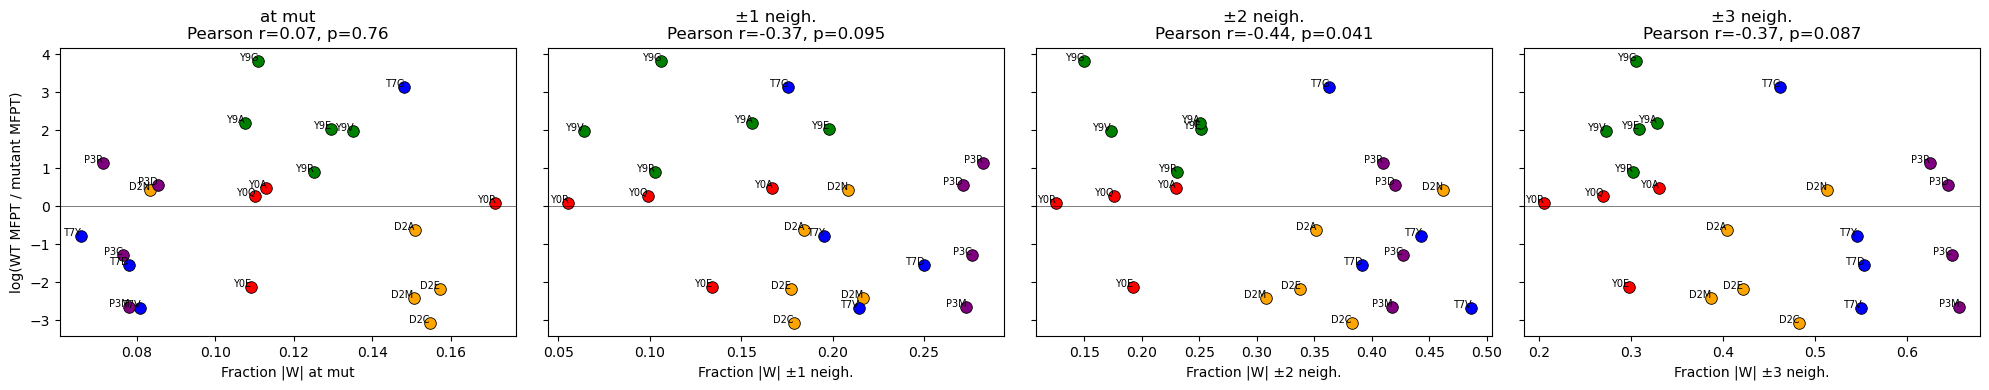

In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from common.consts import res_colors

# inputs: weights_df, y
exclude = {"Y9Q", "D2R", "T7R", "T7Q", "WT"}
pairs = {c: (int(c[1]), int(c[2])) for c in weights_df.columns if c.startswith("d") and len(c) == 3}
residues = sorted({i for ij in pairs.values() for i in ij})

def get_res_idx(shortname: str):
    m = re.search(r"(\d+)", shortname)
    return int(m.group(1)) if m else None

def per_residue_sum_abs(wrow: pd.Series) -> pd.Series:
    s = pd.Series(0.0, index=residues, dtype=float)
    for d,(i,j) in pairs.items():
        v = abs(wrow.get(d, 0.0))
        s[i] += v; s[j] += v
    return s

def seq_neighbors(center: int, radius: int):
    return [r for r in residues if abs(r - center) <= radius and r != center]

def pearson_report(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3: 
        return np.nan, np.nan
    r, p = pearsonr(x[mask], y[mask])
    return r, p

radii = (0, 1, 2)   # 0 = at mutated residue only

rows = []
for mut in weights_df.index:
    if mut in exclude or mut not in y.index:
        continue
    rmut = get_res_idx(mut)
    if rmut is None:
        continue
    w = weights_df.loc[mut].reindex(pairs.keys())
    S = per_residue_sum_abs(w)
    tot = float(S.sum())
    if not np.isfinite(tot) or tot <= 0:
        continue
    entry = {"mut": mut, "res": rmut, "mfpt_change": float(y.loc[mut])}
    entry["frac_r0"] = float(S.get(rmut, 0.0) / tot)
    for R in (1, 2, 3):
        nbrs = seq_neighbors(rmut, R)
        entry[f"frac_r{R}"] = float(S.loc[nbrs].sum() / tot) if len(nbrs) else 0.0
    rows.append(entry)

df = pd.DataFrame(rows).set_index("mut")

# --- plotting side by side ---
cols = [f"frac_r{R}" for R in radii]
fig, axes = plt.subplots(1, len(cols), figsize=(5*len(cols), 4), sharey=True)

for ax, col in zip(axes, cols):
    r, p = pearson_report(df[col].values, df["mfpt_change"].values)
    for mut, row in df.iterrows():
        c = res_colors.get(int(row["res"]), "gray")
        ax.scatter(row[col], row["mfpt_change"], color=c, s=70, edgecolors="k", linewidths=0.6)
        ax.text(row[col], row["mfpt_change"], mut, fontsize=7, ha="right")
    ax.axhline(0, color="k", lw=0.6, alpha=0.6)
    label = "at mut" if col=="frac_r0" else f"±{col[-1]} neigh."
    ax.set_xlabel(f"Fraction |W| {label}")
    ax.set_title(f"{label}\nPearson r={r:.2f}, p={p:.2g}")

axes[0].set_ylabel("log(WT MFPT / mutant MFPT)")
fig.tight_layout()
plt.show()
